Load the file

In [5]:
def readBiopacResults(filename):
    f = open(filename,'r')
    temp = []
    for l in f:
        temp.append(l)
    f.close()

    result = []
    for i in range(0,len(temp)):
        # The dataset is a CSV with headers, so we skip the first row and handle commas
        if i == 0: continue
        q = temp[i].strip().split(',')
        if q:
            result.append([float(val) for val in q])

    return np.array(result)

In [ ]:
%pip install requests numpy matplotlib scipy scikit-learn

Load a public data set with ECG data

In [7]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import numpy as np
import requests

In [ ]:


# 1. Ensure numpy is available for the existing function
# 2. Download a sample ECG dataset (txt format similar to Biopac) from PhysioNet or a public source
url = 'https://raw.githubusercontent.com/neuropsychology/NeuroKit/master/data/ecg_1000hz.csv'
local_filename = 'sample_ecg_data.csv'
fs = 1000
response = requests.get(url)
with open(local_filename, 'wb') as f:
    f.write(response.content)

print(f'Downloaded {local_filename}')

# 4. Call the readBiopacResults function (defined in previous cells)
# Note: This function expects space-separated values based on its implementation
try:
    data = readBiopacResults(local_filename)
    # 5. Verify the shape and content
    print(f'Data Shape: {data.shape}')
    print('First 5 rows of data:')
    print(data[:5])
except Exception as e:
    print(f'Error reading file: {e}')

Downloaded sample_ecg_data.csv
Data Shape: (50000, 1)
First 5 rows of data:
[[0.35361176]
 [0.40294979]
 [0.4494891 ]
 [0.4949316 ]
 [0.5398068 ]]


Pre-Process EEG data

In [ ]:
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y
def preprocess_data(raw_data,fs):
    # 1. Parameters for ECG (Sampling rate is 100Hz based on URL)
    lowcut = 5
    highcut = 15.0
    # 2. Apply Filter
    filtered = bandpass_filter(raw_data, lowcut, highcut, fs, order=2)
    # 3. Z-score Normalization
    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    return normalized

Plot a result

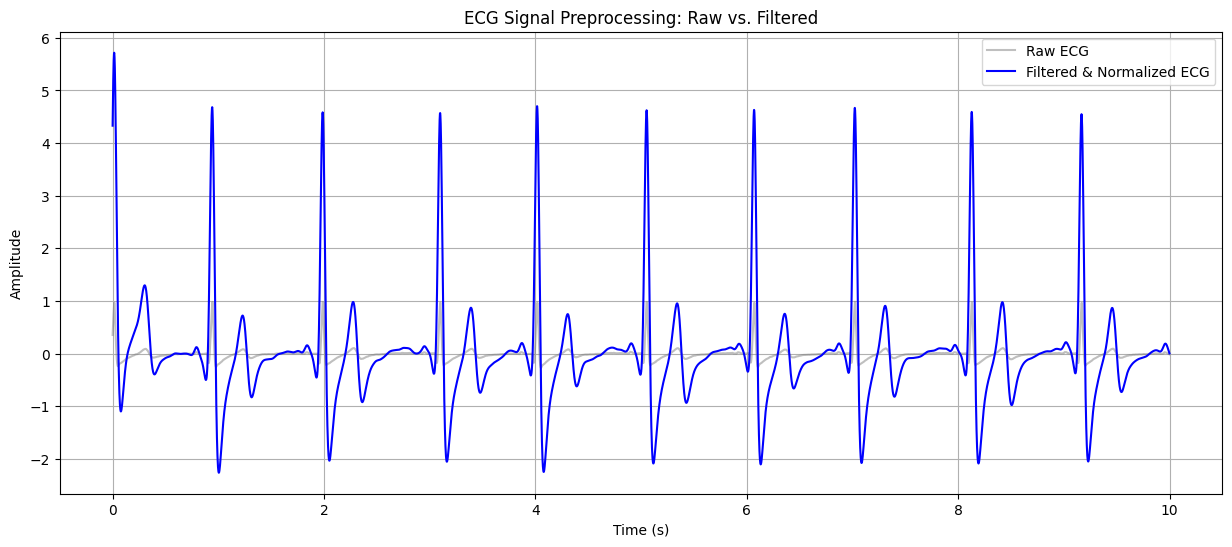

Preprocessing complete: Band-pass (0.5-40Hz) and Z-score normalization applied.


In [ ]:
ecg_raw = data[:, 0]
ecg_normalized = preprocess_data(ecg_raw,fs)

time = np.arange(len(ecg_raw)) / fs
plt.figure(figsize=(15, 6))
plt.plot(time[:(10*fs)], ecg_raw[:(10*fs)], label='Raw ECG', alpha=0.5, color='gray')
plt.plot(time[:(10*fs)], ecg_normalized[:(10*fs)], label='Filtered & Normalized ECG', color='blue')
plt.title('ECG Signal Preprocessing: Raw vs. Filtered')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

print('Preprocessing complete: Band-pass (0.5-40Hz) and Z-score normalization applied.')

Label the Data set

In [13]:
# 4. Use find_peaks to generate ground truth labels
# Setting distance to roughly 0.6s (60 samples at 100Hz) to avoid double counting same heartbeats
peaks, _ = find_peaks(ecg_normalized, distance=600, height=1.5)

# 5. Segment the signal into fixed-size windows
window_size = 1*fs  # 1 second window
half_window = window_size // 2
X = []
y = []

# Create 'Complex' segments (centered on peaks)
for p in peaks:
    if p > half_window and p < len(ecg_normalized) - half_window:
        segment = ecg_normalized[p - half_window : p + half_window]
        X.append(segment)
        y.append(1)  # Class 1: Complex

# Create 'Non-Complex' segments (sampled between peaks)
for i in range(len(peaks) - 1):
    mid_point = (peaks[i] + peaks[i+1]) // 2
    if mid_point > half_window and mid_point < len(ecg_normalized) - half_window:
        segment = ecg_normalized[mid_point - half_window : mid_point + half_window]
        X.append(segment)
        y.append(0)  # Class 0: No Complex

X = np.array(X)
y = np.array(y)

print(f'Detected {len(peaks)} complexes.')
print(f'Final Dataset Shape: X={X.shape}, y={y.shape}')
print(f'Class Distribution: {np.bincount(y)}')

Detected 50 complexes.
Final Dataset Shape: X=(97, 1000), y=(97,)
Class Distribution: [48 49]


Display Training label tests

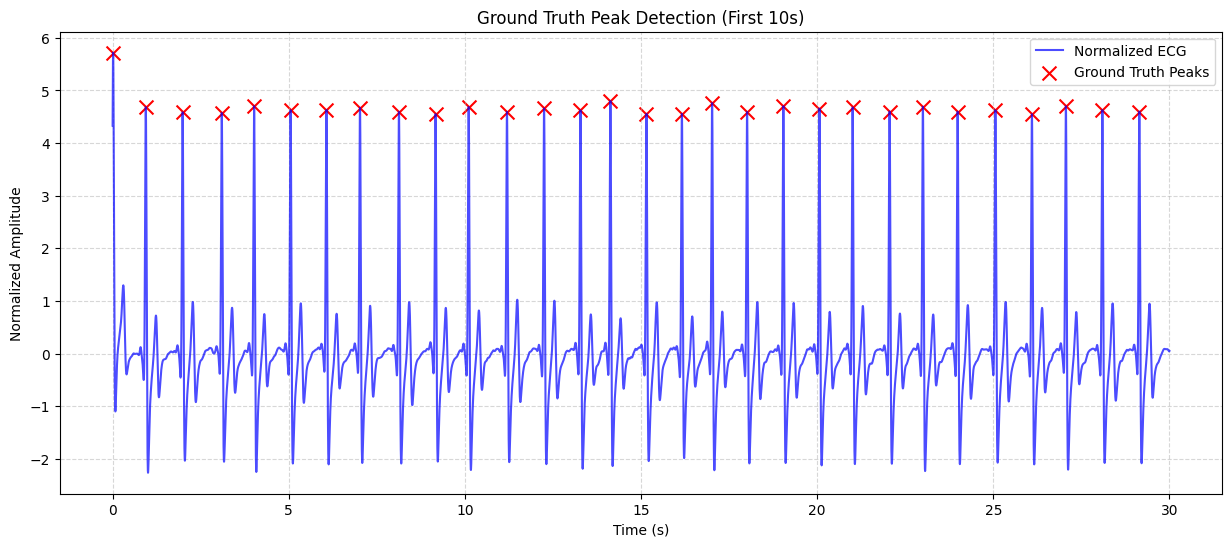

Visualization of the first 30 seconds complete.


In [15]:

# 1. Define the time window for the first 10 seconds
duration = 30
max_index = duration * fs

# 2. Slice the ecg_normalized array and the corresponding time array
# Note: ecg_normalized and time were defined in cells cebe4c36 and 364070df
time_segment = time[:max_index]
signal_segment = ecg_normalized[:max_index]

# 3. Filter the peaks array
filtered_gt_peaks = peaks[peaks < max_index]

# 4. Create the plot
plt.figure(figsize=(15, 6))
plt.plot(time_segment, signal_segment, label='Normalized ECG', color='blue', alpha=0.7)

# 5. Overlay filtered peaks
plt.scatter(time[filtered_gt_peaks], ecg_normalized[filtered_gt_peaks],
            color='red', marker='x', s=100, label='Ground Truth Peaks')

# 6. Add labels and title
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title('Ground Truth Peak Detection (First 10s)')

# 7. Include legend and display
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f'Visualization of the first {duration} seconds complete.')

Verified Training labelling is good, start training.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Split the dataset into training and validation sets (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Fit the model to the training data
rf_model.fit(X_train, y_train)

# 4. Evaluate the model
y_pred = rf_model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)

print(f'Training Set Size: {len(X_train)}')
print(f'Validation Set Size: {len(X_val)}')
print(f'Random Forest Validation Accuracy: {accuracy:.4f}')

Training Set Size: 77
Validation Set Size: 20
Random Forest Validation Accuracy: 1.0000


Test Model on validation dataset.

--- Confusion Matrix ---
[[ 8  0]
 [ 0 12]]

--- Classification Report ---
              precision    recall  f1-score   support

 Non-Complex       1.00      1.00      1.00         8
     Complex       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



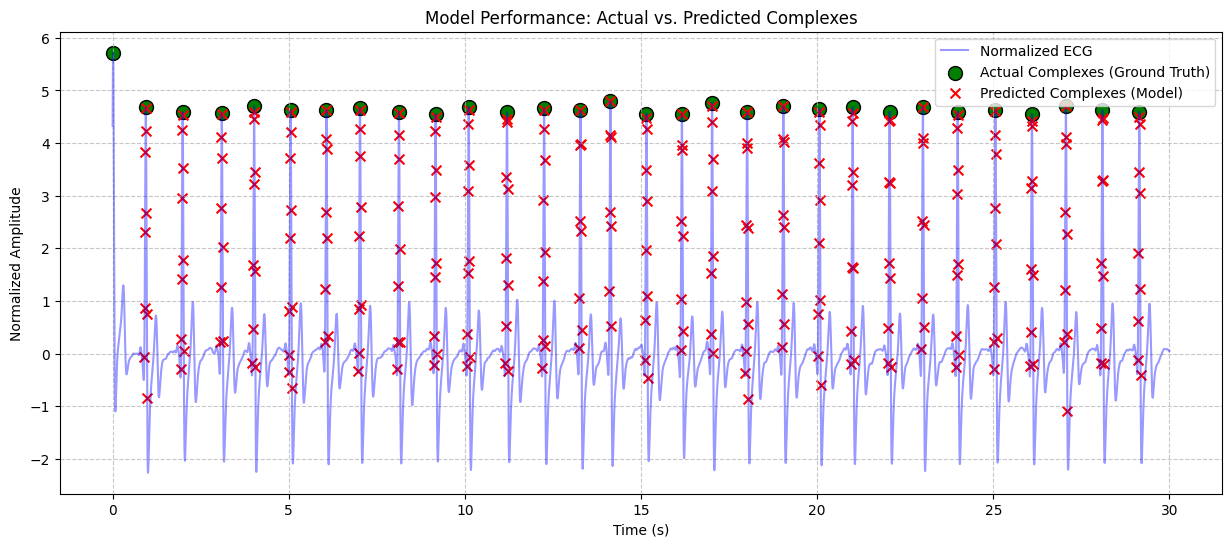

Evaluation and visualization complete.


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 1. Get confidence scores for the 'Complex' class
y_proba = rf_model.predict_proba(X_val)[:, 1]

# 2. Print Evaluation Metrics
print("--- Confusion Matrix ---")
print(confusion_matrix(y_val, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_val, y_pred, target_names=['Non-Complex', 'Complex']))
print("\n Rates")


# 3. Sliding Window Prediction for Visualization
# We'll test on the first 30 seconds (3000 samples)
test_segment_size = 30*fs
test_signal = ecg_normalized[:test_segment_size]
predicted_complex_indices = []

step = 10
for i in range(half_window, test_segment_size - half_window, step):
    window = test_signal[i - half_window : i + half_window].reshape(1, -1)
    if rf_model.predict(window)[0] == 1:
        predicted_complex_indices.append(i)

# 4. Filter ground truth peaks for the same segment
true_peaks_in_segment = peaks[peaks < test_segment_size]

# 5. Visualization
plt.figure(figsize=(15, 6))
plt.plot(time[:test_segment_size], test_signal, label='Normalized ECG', color='blue', alpha=0.4)

# Plot Ground Truth Peaks
plt.scatter(time[true_peaks_in_segment], test_signal[true_peaks_in_segment],
            color='green', marker='o', s=100, label='Actual Complexes (Ground Truth)', edgecolors='black')

# Plot Model Predictions
if predicted_complex_indices:
    plt.scatter(time[predicted_complex_indices], test_signal[predicted_complex_indices],
                color='red', marker='x', s=50, label='Predicted Complexes (Model)')

plt.title('Model Performance: Actual vs. Predicted Complexes')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print('Evaluation and visualization complete.')

Define Method to lerage trained model on new data

In [ ]:
def predict_complexes(raw_data_array, sampling_rate):
    """
    Detects ECG complexes in a raw signal array.

    Args:
        raw_data_array (np.array): Raw ECG signal.
        sampling_rate (int): Sampling frequency in Hz.

    Returns:
        np.array: Indices where complexes were detected.
    """
    ecg_normalized_input = preprocess_data(raw_data_array, sampling_rate)
    # 3. Sliding window mechanism
    window_size = sampling_rate*1 #(1 second each)
    half_win = window_size // 2
    step = 10
    detections = []

    for i in range(half_win, len(ecg_normalized_input) - half_win, step):
        window = ecg_normalized_input[i - half_win : i + half_win].reshape(1, -1)
        # 4. Predict using the trained Random Forest model
        if rf_model.predict(window)[0] == 1:
            detections.append(i)

    return np.array(detections)



Call the model prediction interface

In [ ]:
lab3_Results= readBiopacResults('./Lab-03-L05_ayesha.txt')
sample_rate = 800
test_raw_segment = lab3_Results[:(fs*10),0]#process 10 seconds of data
detected_indices = predict_complexes(test_raw_segment, sample_rate)

test_raw_segment = ecg_raw[:(50*fs)] # Test on first 50 seconds
detected_indices = predict_complexes(test_raw_segment, fs)

print(f'Test completed.')
print(f'Detected {len(detected_indices)} complex points in the test segment.')
print(f'First 10 detected indices: {detected_indices[:10]}')




Plot the output

In [ ]:
samples = 11 * sample_rate

# 2. Create time array for the X-axis for the first 10 seconds (1000 samples)
time_segment = np.arange(samples) / fs
signal_segment = test_raw_segment[:samples]

# 3. Filter detected_indices to those within the first 1000 samples
filtered_detections = detected_indices[detected_indices < samples]

# 4. Plot the raw signal segment
plt.figure(figsize=(15, 6))
plt.plot(time_segment, signal_segment, label='Raw Biopac ECG', color='black', alpha=0.7)

# 5. Overlay detected complexes with red markers
plt.scatter(filtered_detections / fs, signal_segment[filtered_detections],
            color='red', marker='x', s=80, label='Model Detected Complexes')

# 6. Add labels, title, and legend
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Biopac ECG: Detected Complexes (First 10s)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f'Visualization of the first {samples/fs} seconds complete.')